<a href="https://colab.research.google.com/github/ParthHarde/breast-cancer-project/blob/main/metabric/01_metabric_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/breast-cancer-project/metabric"
for sub in ["data/raw", "data/processed", "models", "results"]:
    os.makedirs(f"{BASE}/{sub}", exist_ok=True)
print(os.listdir(BASE))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['data', 'models', 'results']


In [38]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"parthharde","key":"af3528307f964a92be35e496d56da9d3"}'}

In [39]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [40]:
!kaggle datasets download -d raghadalharbi/breast-cancer-gene-expression-profiles-metabric -p "{BASE}/data/raw" --unzip
!ls -lh "{BASE}/data/raw"

Dataset URL: https://www.kaggle.com/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric
License(s): DbCL-1.0
100% 2.72M/2.72M [00:00<00:00, 60.3MB/s]

total 8.1M
-rw------- 1 root root 8.1M Oct  4 18:21 METABRIC_RNA_Mutation.csv


In [41]:
import pandas as pd
df = pd.read_csv(f"{BASE}/data/raw/METABRIC_RNA_Mutation.csv", low_memory=False)
print(df.shape)
df.head()

(1904, 693)


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [42]:
df.info(max_cols=40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB


In [43]:
print(list(df.columns[:35]))

['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten']


In [44]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"missing": missing, "percent": missing_pct}).head(15))

                                missing  percent
tumor_stage                         501     26.3
3-gene_classifier_subtype           204     10.7
primary_tumor_laterality            106      5.6
neoplasm_histologic_grade            72      3.8
cellularity                          54      2.8
mutation_count                       45      2.4
er_status_measured_by_ihc            30      1.6
type_of_breast_surgery               22      1.2
tumor_size                           20      1.1
oncotree_code                        15      0.8
tumor_other_histologic_subtype       15      0.8
cancer_type_detailed                 15      0.8
death_from_cancer                     1      0.1
akr1c1                                0      0.0
akr1c2                                0      0.0


In [45]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient IDs:", df["patient_id"].duplicated().sum())

Duplicate rows: 0
Duplicate patient IDs: 0


In [46]:
print(df.dtypes.value_counts())   # how many numeric vs text columns

float64    498
object     190
int64        5
Name: count, dtype: int64


In [47]:
print(df.shape)

(1904, 693)


In [48]:
for col in ["overall_survival", "death_from_cancer", "overall_survival_months"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(10))


--- overall_survival ---
overall_survival
0    1103
1     801
Name: count, dtype: int64

--- death_from_cancer ---
death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
NaN                       1
Name: count, dtype: int64

--- overall_survival_months ---
overall_survival_months
192.200000    4
164.333333    3
48.433333     3
34.700000     3
152.066667    3
98.700000     3
117.666667    3
150.600000    3
43.100000     3
38.033333     3
Name: count, dtype: int64


In [49]:
print(pd.crosstab(df["overall_survival"], df["death_from_cancer"], dropna=False))

death_from_cancer  Died of Disease  Died of Other Causes  Living  NaN
overall_survival                                                     
0                              622                   480       0    1
1                                0                     0     801    0


In [50]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient IDs:", df["patient_id"].duplicated().sum())
print(df.dtypes.value_counts())

Duplicate rows: 0
Duplicate patient IDs: 0
float64    498
object     190
int64        5
Name: count, dtype: int64


In [51]:
clinical = df.iloc[:, :31]
summary = pd.DataFrame({
    "dtype": clinical.dtypes,
    "unique_values": clinical.nunique(),
    "missing": clinical.isnull().sum()
})
print(summary)

                                  dtype  unique_values  missing
patient_id                        int64           1904        0
age_at_diagnosis                float64           1572        0
type_of_breast_surgery           object              2       22
cancer_type                      object              2        0
cancer_type_detailed             object              6       15
cellularity                      object              3       54
chemotherapy                      int64              2        0
pam50_+_claudin-low_subtype      object              7        0
cohort                          float64              5        0
er_status_measured_by_ihc        object              2       30
er_status                        object              2        0
neoplasm_histologic_grade       float64              3       72
her2_status_measured_by_snp6     object              4        0
her2_status                      object              2        0
tumor_other_histologic_subtype   object 

In [52]:
print("df loaded:", "df" in globals())
print(df.shape)
print("BASE =", BASE)

df loaded: True
(1904, 693)
BASE = /content/drive/MyDrive/breast-cancer-project/metabric


In [53]:
import numpy as np
import pandas as pd

clinical_cols = list(df.columns[:31])
genomic_cols  = list(df.columns[31:])
expr_cols = [c for c in genomic_cols if df[c].dtype != "object"]
mut_cols  = [c for c in genomic_cols if df[c].dtype == "object"]

print(len(clinical_cols), len(expr_cols), len(mut_cols))   # expect 31 489 173

31 489 173


In [54]:
for c in mut_cols[:3]:
    print(c, "->", df[c].unique()[:8])

print("Missing values in mutation columns:", df[mut_cols].isnull().sum().sum())

pik3ca_mut -> ['0' 'H1047R' 'E542K' 'Q546H G1049R' 'E545K' 'N345K E81K' 'H1047L E726K'
 'H1047L']
tp53_mut -> ['0' 'H178P' 'S241F' 'P67Qfs*56' 'C242R' 'C135R' 'S303Efs*3' 'R273C']
muc16_mut -> ['0' 'R5550S' 'P6040R' 'E2017V' 'E3861*' 'R8636I' 'S248Y' 'P6073L']
Missing values in mutation columns: 0


In [55]:
X_mut = (~df[mut_cols].astype(str).isin(["0", "0.0"])).astype(int)

print(X_mut.sum().sort_values(ascending=False).head(5))
print("Unique values in X_mut:", np.unique(X_mut.values))

pik3ca_mut    795
tp53_mut      659
muc16_mut     326
ahnak2_mut    311
kmt2c_mut     234
dtype: int64
Unique values in X_mut: [0 1]


In [56]:
target = "overall_survival"
drop_cols = ["patient_id", "cohort", "death_from_cancer",
             "overall_survival_months", target]
clinical_features = [c for c in clinical_cols if c not in drop_cols]

X = pd.concat([df[clinical_features], df[expr_cols], X_mut], axis=1)
y = df[target]

assert X.columns.is_unique
assert target not in X.columns and "death_from_cancer" not in X.columns
print(X.shape, y.shape)    # expect (1904, 688) (1904,)

(1904, 688) (1904,)


In [57]:
num_clin = [c for c in clinical_features if df[c].dtype != "object"]
cat_clin = [c for c in clinical_features if df[c].dtype == "object"]
mut_features = list(X_mut.columns)

print(len(num_clin), len(cat_clin), len(expr_cols), len(mut_features))  # expect 10 16 489 173
print("Numeric clinical:", num_clin)
print("Text clinical:", cat_clin)

10 16 489 173
Numeric clinical: ['age_at_diagnosis', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage']
Text clinical: ['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'pam50_+_claudin-low_subtype', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'oncotree_code', 'pr_status', '3-gene_classifier_subtype']


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_clin),
    ("cat", cat_pipe, cat_clin),
    ("expr", StandardScaler(), expr_cols),
    ("mut", "passthrough", mut_features),
])

In [59]:
import os, json

os.makedirs(f"{BASE}/data/processed", exist_ok=True)

clean = pd.concat([df[["patient_id"]], X, y], axis=1)
clean.to_csv(f"{BASE}/data/processed/metabric_clean.csv", index=False)
print(clean.shape)    # expect (1904, 690)

groups = {"num_clin": num_clin, "cat_clin": cat_clin,
          "expr_cols": expr_cols, "mut_features": mut_features}
with open(f"{BASE}/data/processed/feature_groups.json", "w") as f:
    json.dump(groups, f)

(1904, 690)


In [60]:
import numpy as np
import pandas as pd

clinical_cols = list(df.columns[:31])
genomic_cols  = list(df.columns[31:])
expr_cols = [c for c in genomic_cols if df[c].dtype != "object"]
mut_cols  = [c for c in genomic_cols if df[c].dtype == "object"]

print(len(clinical_cols), len(expr_cols), len(mut_cols))   # expect 31 489 173

31 489 173


In [61]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=42)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y.iloc[idx_temp], random_state=42)

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, len(yy), "living share:", round(yy.mean(), 3))

train 1332 living share: 0.42
val 286 living share: 0.423
test 286 living share: 0.42


In [62]:
split_df = pd.concat([
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_train].values, "split": "train"}),
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_val].values,   "split": "val"}),
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_test].values,  "split": "test"}),
])
split_df.to_csv(f"{BASE}/data/processed/split_ids.csv", index=False)
print(split_df["split"].value_counts())

split
train    1332
val       286
test      286
Name: count, dtype: int64


In [63]:
preprocessor.fit(X_train)                 # learns from TRAIN only
Xtr  = preprocessor.transform(X_train)
Xval = preprocessor.transform(X_val)      # applies the same numbers, learns nothing new
Xte  = preprocessor.transform(X_test)
print(Xtr.shape, Xval.shape, Xte.shape)

(1332, 748) (286, 748) (286, 748)


In [64]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, y_train)
print("Baseline validation accuracy:", round(dummy.score(Xval, y_val), 3))   # about 0.58

Baseline validation accuracy: 0.577


In [65]:
derived = ["pam50_+_claudin-low_subtype", "integrative_cluster", "3-gene_classifier_subtype"]
web_features = [c for c in num_clin + cat_clin if c not in derived]
print(len(web_features), web_features)

23 ['age_at_diagnosis', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'primary_tumor_laterality', 'oncotree_code', 'pr_status']


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

train = X_train.copy()
train["survival"] = y_train.map({0: "Deceased", 1: "Living"})

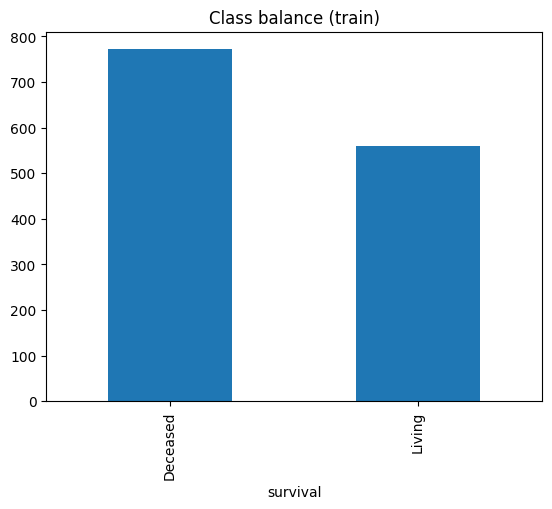

In [67]:
train["survival"].value_counts().plot(kind="bar", title="Class balance (train)")
plt.show()

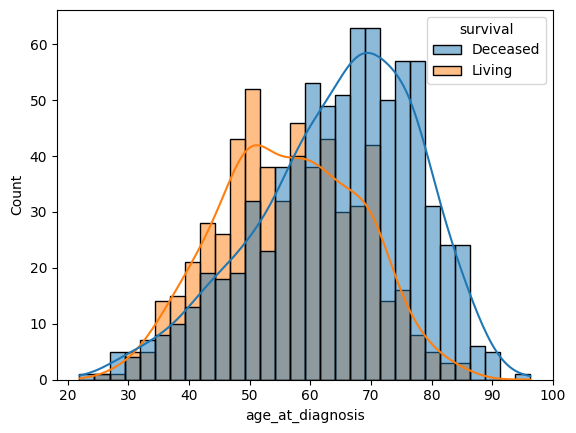

In [68]:
sns.histplot(data=train, x="age_at_diagnosis", hue="survival", kde=True, bins=30)
plt.show()

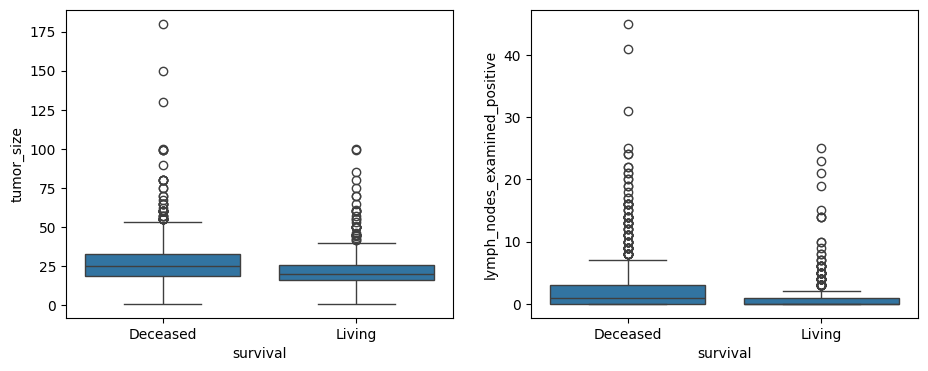

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=train, x="survival", y="tumor_size", ax=ax[0])
sns.boxplot(data=train, x="survival", y="lymph_nodes_examined_positive", ax=ax[1])
plt.show()

In [70]:
for col in ["er_status", "her2_status", "chemotherapy", "tumor_stage"]:
    print(train.groupby(col)["survival"].apply(lambda s: (s == "Living").mean()).round(2), "\n")

er_status
Negative    0.44
Positive    0.41
Name: survival, dtype: float64 

her2_status
Negative    0.43
Positive    0.36
Name: survival, dtype: float64 

chemotherapy
0    0.41
1    0.48
Name: survival, dtype: float64 

tumor_stage
0.0    0.50
1.0    0.55
2.0    0.39
3.0    0.26
4.0    0.11
Name: survival, dtype: float64 



In [71]:
num_train = X_train[num_clin].copy()
num_train["target"] = y_train
print(num_train.corr()["target"].drop("target").sort_values())

age_at_diagnosis                -0.304134
tumor_stage                     -0.191115
lymph_nodes_examined_positive   -0.175968
tumor_size                      -0.171307
nottingham_prognostic_index     -0.151983
neoplasm_histologic_grade       -0.090117
mutation_count                  -0.078506
hormone_therapy                 -0.045233
chemotherapy                     0.058588
radio_therapy                    0.101756
Name: target, dtype: float64


In [72]:
print((X_train[num_clin + cat_clin].isnull().mean() * 100).round(1).sort_values(ascending=False).head(8))

tumor_stage                  26.1
3-gene_classifier_subtype    10.7
primary_tumor_laterality      5.1
neoplasm_histologic_grade     3.6
cellularity                   2.4
mutation_count                2.3
er_status_measured_by_ihc     1.2
tumor_size                    0.9
dtype: float64
